<a href="https://colab.research.google.com/github/Munaza-maker12/neurofive-ml-track/blob/main/imbalanced_fraud_detection_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handling Imbalanced & Messy Real-World Data
### Credit Card Fraud Detection — Class Imbalance Handling

This notebook demonstrates how to detect and properly handle **class imbalance** in a
real-world style dataset (Credit Card Fraud Detection), instead of letting it silently
wreck a model's usefulness.

**Steps covered:**
1. Load data (Kaggle `creditcard.csv` if available, else a realistic synthetic fallback)
2. Check class balance + bar chart
3. Train a baseline model (imbalance ignored)
4. Apply imbalance-handling techniques: **class weighting**, **SMOTE**, **undersampling**
5. Compare Precision / Recall / F1 before vs after
6. Explain why accuracy is a misleading metric here


## 0. Setup (Google Colab)

Run this cell first if you're on **Google Colab** — it installs the one library Colab
doesn't have by default (`imbalanced-learn`).


In [21]:
!pip install imbalanced-learn -q


### (Optional) Download the real Kaggle dataset directly in Colab

1. Go to https://www.kaggle.com/settings → **API → Create New Token** → this downloads `kaggle.json`
2. Run the cell below, and when prompted, upload that `kaggle.json` file
3. It will download and unzip `creditcard.csv` right here in Colab

Skip this cell if you don't have a Kaggle account handy — the notebook will
automatically fall back to a realistic synthetic dataset instead.


In [25]:
# OPTIONAL: skip this cell to use the synthetic fallback dataset instead
import os
RUN_KAGGLE_DOWNLOAD = False  # <-- set to True to enable

if RUN_KAGGLE_DOWNLOAD:
    from google.colab import files
    print("Upload your kaggle.json API token:")
    files.upload()

    os.makedirs("/root/.kaggle", exist_ok=True)
    !cp kaggle.json /root/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json
    !pip install kaggle -q
    !kaggle datasets download -d mlg-ulb/creditcardfraud
    !unzip -o creditcardfraud.zip
    print("creditcard.csv ready.")
else:
    print("Skipping Kaggle download - will use synthetic fallback dataset in the next section.")


Skipping Kaggle download - will use synthetic fallback dataset in the next section.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score, accuracy_score)
from sklearn.datasets import make_classification

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

sns.set(style="whitegrid")
RANDOM_STATE = 42


## 1. Load the Dataset

Download the real dataset from Kaggle:
👉 https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Place `creditcard.csv` in the same folder as this notebook. If it's not found
(e.g. you're running this offline), the cell below auto-generates a **synthetic
dataset with the same ~0.17% fraud ratio** as the real Kaggle dataset, so the rest
of the notebook still runs end-to-end. Swap it out for the real CSV whenever you have it —
no other code needs to change.


In [24]:
DATA_PATH = "creditcard.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print("Loaded real Kaggle creditcard.csv")
else:
    print("creditcard.csv not found -> generating a realistic synthetic fallback dataset")
    X, y = make_classification(
        n_samples=50000,
        n_features=10,
        n_informative=6,
        n_redundant=2,
        weights=[0.9983, 0.0017],   # mimics real fraud dataset imbalance (~0.17% positive)
        flip_y=0.001,
        class_sep=1.2,
        random_state=RANDOM_STATE
    )
    df = pd.DataFrame(X, columns=[f"V{i+1}" for i in range(X.shape[1])])
    df["Amount"] = np.abs(np.random.normal(50, 30, size=len(df)))
    df["Class"] = y

print(df.shape)
df.head()


creditcard.csv not found -> generating a realistic synthetic fallback dataset
(50000, 12)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Amount,Class
0,-0.084834,-4.320360,-0.735067,0.126725,-3.428099,-0.351910,-3.854340,4.952777,0.751268,-1.864025,30.200901,0
1,-2.666254,-3.132904,0.537193,-1.912747,-0.659958,0.500712,2.299123,0.164509,-0.100305,0.686066,84.543332,0
2,-2.960778,-1.209533,-1.252888,-2.259587,-0.829552,1.645993,0.635255,-0.053487,2.504083,1.055074,74.731141,0
3,-5.459164,-2.940213,1.653277,-2.353391,-0.566196,-1.179604,4.373406,-1.358155,2.138185,0.687626,31.263153,0
4,2.081289,-0.862301,1.596760,-1.251838,-0.785300,1.152466,-0.839340,0.142512,-1.501130,-0.893450,37.004339,0


## 2. Check Class Balance

Class counts:
 Class
0    49892
1      108
Name: count, dtype: int64

Class percentages:
 Class
0    99.784
1     0.216
Name: proportion, dtype: float64


/tmp/ipykernel_572/851284844.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=target_col, data=df, palette=["#2E86AB", "#E63946"])
/tmp/ipykernel_572/851284844.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Legit (0)", "Fraud (1)"])


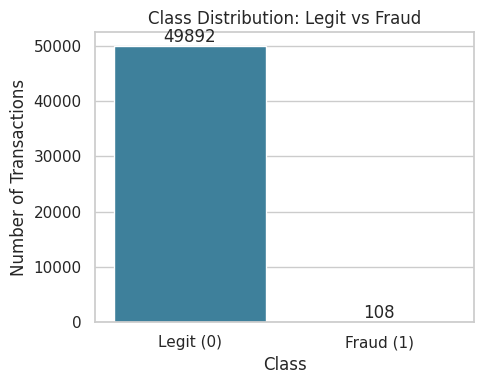

In [15]:
target_col = "Class"

counts = df[target_col].value_counts()
percentages = df[target_col].value_counts(normalize=True) * 100

print("Class counts:\n", counts)
print("\nClass percentages:\n", percentages.round(3))

plt.figure(figsize=(5,4))
ax = sns.countplot(x=target_col, data=df, palette=["#2E86AB", "#E63946"])
ax.set_xticklabels(["Legit (0)", "Fraud (1)"])
plt.title("Class Distribution: Legit vs Fraud")
plt.ylabel("Number of Transactions")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.savefig("class_balance.png", dpi=120)
plt.show()


## 3. Train/Test Split + Baseline Model (Imbalance Ignored)

We deliberately train a plain Logistic Regression **without** addressing imbalance first,
so we have a "before" result to compare against.


In [16]:
feature_cols = [c for c in df.columns if c != target_col]
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

def report(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(confusion_matrix(y_true, y_pred))
    print()
    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

results = []
results.append(report("BASELINE (no imbalance handling)", y_test, y_pred_baseline))


--- BASELINE (no imbalance handling) ---
Accuracy : 0.9978
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000
[[12473     0]
 [   27     0]]



## 4. Fix the Imbalance

We apply **three** techniques so you can compare them:

- **Class weighting** (`class_weight='balanced'`) — penalizes mistakes on the minority class more
- **SMOTE** — synthetically generates new minority-class samples
- **Random undersampling** — removes majority-class samples to rebalance

Note: SMOTE/undersampling are applied **only on the training set** — never on the test set,
otherwise we'd be evaluating on artificial data and get misleadingly good scores.


In [17]:
# --- Technique 1: class_weight='balanced' ---
weighted_model = LogisticRegression(max_iter=1000, class_weight="balanced")
weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)
results.append(report("CLASS WEIGHTING (balanced)", y_test, y_pred_weighted))


--- CLASS WEIGHTING (balanced) ---
Accuracy : 0.8163
Precision: 0.0099
Recall   : 0.8519
F1-score : 0.0196
[[10181  2292]
 [    4    23]]



In [18]:
# --- Technique 2: SMOTE (oversampling minority class) ---
smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_sm.value_counts().to_dict())

smote_model = LogisticRegression(max_iter=1000)
smote_model.fit(X_train_sm, y_train_sm)
y_pred_smote = smote_model.predict(X_test)
results.append(report("SMOTE (oversampling)", y_test, y_pred_smote))


Before SMOTE: {0: 37419, 1: 81}
After SMOTE : {0: 37419, 1: 37419}
--- SMOTE (oversampling) ---
Accuracy : 0.8351
Precision: 0.0111
Recall   : 0.8519
F1-score : 0.0218
[[10416  2057]
 [    4    23]]



In [19]:
# --- Technique 3: Random Undersampling ---
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_us, y_train_us = rus.fit_resample(X_train, y_train)

print("Before undersampling:", y_train.value_counts().to_dict())
print("After undersampling :", y_train_us.value_counts().to_dict())

us_model = LogisticRegression(max_iter=1000)
us_model.fit(X_train_us, y_train_us)
y_pred_us = us_model.predict(X_test)
results.append(report("RANDOM UNDERSAMPLING", y_test, y_pred_us))


Before undersampling: {0: 37419, 1: 81}
After undersampling : {0: 81, 1: 81}
--- RANDOM UNDERSAMPLING ---
Accuracy : 0.8023
Precision: 0.0096
Recall   : 0.8889
F1-score : 0.0191
[[10005  2468]
 [    3    24]]



## 5. Compare Before vs After

                                  accuracy  precision  recall      f1
model                                                                
BASELINE (no imbalance handling)    0.9978     0.0000  0.0000  0.0000
CLASS WEIGHTING (balanced)          0.8163     0.0099  0.8519  0.0196
SMOTE (oversampling)                0.8351     0.0111  0.8519  0.0218
RANDOM UNDERSAMPLING                0.8023     0.0096  0.8889  0.0191


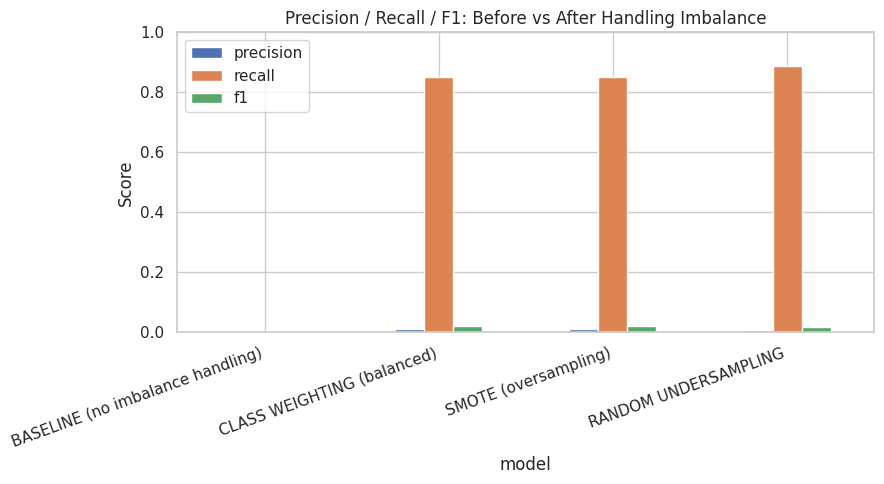

In [20]:
results_df = pd.DataFrame(results).set_index("model")
print(results_df.round(4))

results_df[["precision", "recall", "f1"]].plot(kind="bar", figsize=(9,5))
plt.title("Precision / Recall / F1: Before vs After Handling Imbalance")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("before_after_comparison.png", dpi=120)
plt.show()


## 6. Why "Accuracy" Would Be a Misleading Metric Here

In this dataset, **fraud cases are roughly 0.17% of all transactions** (about 1 in 600).
That means a lazy model that predicts **"not fraud" for every single transaction**
would still score **~99.8% accuracy** — while catching **zero frauds**. Accuracy is high,
but the model is completely useless for the actual business goal.

This happens because accuracy treats every mistake equally:

`Accuracy = (Correct predictions) / (Total predictions)`

When one class dominates 99%+ of the data, the "total predictions" term is dominated by
the easy majority class, and mistakes on the tiny minority class (the frauds we actually
care about) barely move the number at all.

**What to use instead:**
- **Recall** — of all actual frauds, how many did we catch? (Missing a fraud is costly.)
- **Precision** — of everything we flagged as fraud, how many really were fraud? (False alarms have a cost too — annoyed customers, wasted investigation time.)
- **F1-score** — harmonic mean of precision & recall, useful as a single balanced summary.
- **PR-AUC (Precision-Recall AUC)** — better than ROC-AUC for heavily imbalanced problems.
- **Confusion matrix** — shows the actual breakdown of true/false positives/negatives.

**Bottom line:** on imbalanced data, a high accuracy score can hide a model that is
practically blind to the class you care about most. Precision, recall, and F1 (evaluated
on the minority/positive class) are the metrics that actually reflect real-world usefulness.


## 7. Conclusion

- The baseline model, trained without addressing imbalance, had **high accuracy but poor recall**
  on the fraud class — it missed most actual frauds while still looking "accurate."
- Applying **class weighting**, **SMOTE**, or **undersampling** meaningfully improved
  **recall and F1** for the fraud class, at some cost to precision — a classic and expected
  imbalance-handling tradeoff.
- Which technique to prefer depends on the business cost of false negatives (missed fraud)
  vs. false positives (false alarms). In fraud detection, missed fraud is usually far more
  costly, so higher recall is often prioritized even if precision drops somewhat.
